# Students Performance Analysis

## Setup

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading & Preprocessing 

In [33]:
students_performance = pd.read_csv('../data/StudentsPerformance.csv')

In [34]:
students_performance.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [35]:
students_performance.shape

(1000, 8)

In [36]:
students_performance.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [37]:
students_performance.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [38]:
null_counts = students_performance.isnull().sum()
print(null_counts)

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [39]:
duplicate_counts = students_performance.duplicated().sum()
print(duplicate_counts)

0


In [40]:
# gender, race/ethnicity, parental level of education, lunch, test preparation course
from sklearn.preprocessing import LabelEncoder
LabelEncoder = LabelEncoder()
students_performance['gender'] = LabelEncoder.fit_transform(students_performance['gender'])
students_performance['race/ethnicity'] = LabelEncoder.fit_transform(students_performance['race/ethnicity'])
students_performance['parental level of education'] = LabelEncoder.fit_transform(students_performance['parental level of education'])
students_performance['lunch'] = LabelEncoder.fit_transform(students_performance['lunch'])
students_performance['test preparation course'] = LabelEncoder.fit_transform(students_performance['test preparation course'])
students_performance.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,0,1,1,1,1,72,72,74
1,0,2,4,1,0,69,90,88
2,0,1,3,1,1,90,95,93
3,1,0,0,0,1,47,57,44
4,1,2,4,1,1,76,78,75


In [41]:
y = students_performance['math score']
X = students_performance.drop('math score', axis=1)

## EDA

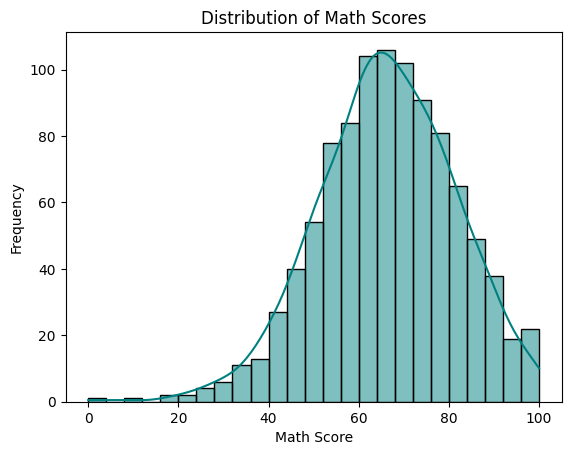

In [44]:
sns.histplot(students_performance['math score'], color='teal', kde=True)
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.show()

64-68 - most frequent score
60-72 - top 3
40-100 - 90% + 

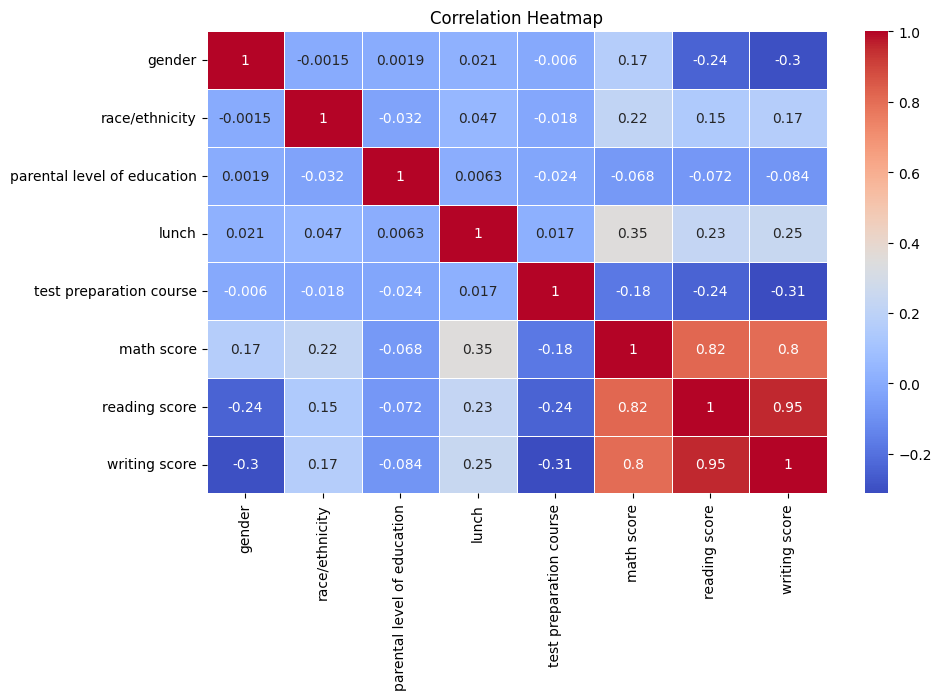

In [45]:
# Heatmap to visualize correlations
plt.figure(figsize=(10, 6))
sns.heatmap(students_performance.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

major corelation of math score with others:
reading score - 0.82
writing score - 0.8

minor corelation of match score with others:
gender - 0.17
race/ethincity - 0.22

below Average corelation of match score with others:
lunch - 0.35

negative corelation of match score with others:
parental level of education - -0.068
test preparation course - -0.18

C:\Users\Vaibhav\AppData\Local\Temp\ipykernel_19152\121218735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='test preparation course', y='math score', data=students_performance, palette='Set2')


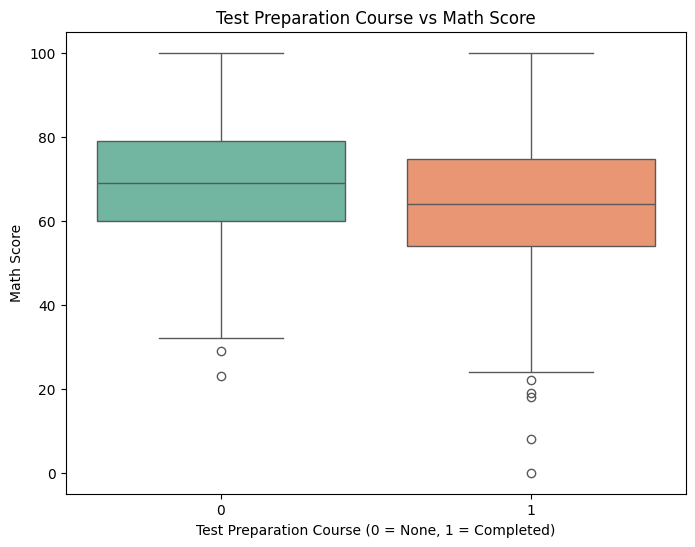

In [46]:
# Box plot to visualize test preparation course vs math score
plt.figure(figsize=(8, 6))
sns.boxplot(x='test preparation course', y='math score', data=students_performance, palette='Set2')
plt.title('Test Preparation Course vs Math Score')
plt.xlabel('Test Preparation Course (0 = None, 1 = Completed)')
plt.ylabel('Math Score')
plt.show()

test score 0 - 60-80
test score 1 - 55-75